In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
from sklearn.metrics import make_scorer

In [2]:
Aus = pd.read_csv("Data/AustraliaGPModified.csv")
Jap = pd.read_csv("Data/JapanGPModified.csv")

In [3]:
Aus

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_Laptime(s),Longest_Stint,Qualifying_Time(s),Starting_Pos,Race_Result,rain_probability,Temprature,Tyre_Compound_MEDIUM,Tyre_Compound_SOFT
0,ALB,83.130,81.847000,81.664000,36.650031,20.898312,42.942393,100.398929,11,80.941,15.0,12.0,0,19.88,False,False
1,ANT,81.376,79.943000,80.324000,36.042935,19.788161,41.798556,95.665077,15,78.811,2.0,2.0,0,19.88,False,False
2,BEA,82.682,81.326000,80.778000,39.039839,20.835774,41.873786,102.072750,15,80.311,12.0,7.0,0,19.88,False,False
3,BOR,81.696,81.668000,80.459000,39.209964,20.777286,46.708920,99.549182,9,80.221,10.0,9.0,0,19.88,True,False
4,BOT,84.022,83.660000,83.514000,37.285821,20.556821,43.604600,101.500360,15,83.244,19.0,19.0,0,19.88,True,False
5,COL,83.325,82.619000,81.413000,38.297846,22.258222,45.171583,101.418318,11,81.270,16.0,14.0,0,19.88,True,False
6,GAS,84.035,82.167000,81.071000,37.261133,22.742125,41.458429,99.050308,11,80.501,14.0,10.0,0,19.88,True,False
7,HAD,81.087,80.941000,80.137000,36.938357,23.917321,42.749958,99.028217,13,79.303,3.0,20.0,0,19.88,True,False
8,HAM,80.736,80.050000,79.669000,36.481677,21.753969,43.648655,99.920000,13,79.478,7.0,4.0,0,19.88,False,False
9,HUL,81.969,81.351000,81.067000,34.139485,20.528765,41.426839,93.962483,10,80.303,11.0,22.0,0,19.88,True,False


In [4]:
X = Aus.drop(columns=['Driver','Race_Result','rain_probability','Temprature','Tyre_Compound_MEDIUM','Tyre_Compound_SOFT'])
y = Aus['Race_Result']

In [5]:
X

,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_Laptime(s),Longest_Stint,Qualifying_Time(s),Starting_Pos
0,83.130,81.847000,81.664000,36.650031,20.898312,42.942393,100.398929,11,80.941,15.0
1,81.376,79.943000,80.324000,36.042935,19.788161,41.798556,95.665077,15,78.811,2.0
2,82.682,81.326000,80.778000,39.039839,20.835774,41.873786,102.072750,15,80.311,12.0
3,81.696,81.668000,80.459000,39.209964,20.777286,46.708920,99.549182,9,80.221,10.0
4,84.022,83.660000,83.514000,37.285821,20.556821,43.604600,101.500360,15,83.244,19.0
5,83.325,82.619000,81.413000,38.297846,22.258222,45.171583,101.418318,11,81.270,16.0
6,84.035,82.167000,81.071000,37.261133,22.742125,41.458429,99.050308,11,80.501,14.0
7,81.087,80.941000,80.137000,36.938357,23.917321,42.749958,99.028217,13,79.303,3.0
8,80.736,80.050000,79.669000,36.481677,21.753969,43.648655,99.920000,13,79.478,7.0
9,81.969,81.351000,81.067000,34.139485,20.528765,41.426839,93.962483,10,80.303,11.0


In [6]:
y

0     12.0
1      2.0
2      7.0
3      9.0
4     19.0
5     14.0
6     10.0
7     20.0
8      4.0
9     22.0
10    13.0
11     3.0
12     8.0
13     5.0
14    11.0
15    16.0
16    21.0
17     1.0
18    15.0
19     6.0
Name: Race_Result, dtype: float64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.3, random_state = 42)

In [8]:
model = RandomForestRegressor()

In [9]:
parameter ={
    'n_estimators': [20,25,50,70,75],
    'max_samples' :[3,4,5,6,7,8,9,10]
}

In [10]:
regcv = GridSearchCV(model, param_grid=parameter, cv=3, scoring='neg_root_mean_squared_error')

In [11]:
regcv.fit(X_train, y_train)

/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/ensemble/_for

,estimator,RandomForestRegressor()
,param_grid,"{'max_samples': [3, 4, ...], 'n_estimators': [20, 25, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,25


In [12]:
y_predict = regcv.predict(X)

In [13]:
Final = Aus.copy()
Final['Predicted'] = y_predict

In [14]:
Final = Final.sort_values(by=['Predicted'])

In [15]:
Final = Final.reset_index(drop=True)
Final['Predicted_Pos'] = Final.index+1

In [16]:
Final

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_Laptime(s),Longest_Stint,Qualifying_Time(s),Starting_Pos,Race_Result,rain_probability,Temprature,Tyre_Compound_MEDIUM,Tyre_Compound_SOFT,Predicted,Predicted_Pos
0,RUS,81.371,80.049000,79.053000,38.616071,20.045714,42.000042,101.140833,13,78.518,1.0,1.0,0,19.88,False,False,10.36,1
1,VER,80.789,80.366000,80.197000,37.872231,19.745000,41.107000,93.862300,5,83.244,20.0,6.0,0,19.88,True,False,10.48,2
2,NOR,84.391,80.794000,80.443000,33.216286,20.360862,42.638692,92.236042,16,79.475,6.0,5.0,0,19.88,False,True,10.60,3
3,ANT,81.376,79.943000,80.324000,36.042935,19.788161,41.798556,95.665077,15,78.811,2.0,2.0,0,19.88,False,False,10.76,4
4,LEC,80.267,80.291000,79.827000,37.004633,20.809667,45.400444,99.486360,10,79.327,4.0,3.0,0,19.88,False,False,11.12,5
5,PIA,81.342,79.729000,80.087000,36.638115,20.288808,43.384000,96.971182,10,79.380,5.0,21.0,0,19.88,False,False,11.16,6
6,BOR,81.696,81.668000,80.459000,39.209964,20.777286,46.708920,99.549182,9,80.221,10.0,9.0,0,19.88,True,False,11.36,7
7,OCO,82.161,81.179000,80.983000,39.771345,20.526621,45.612115,102.046375,10,80.491,13.0,11.0,0,19.88,False,False,11.64,8
8,HAM,80.736,80.050000,79.669000,36.481677,21.753969,43.648655,99.920000,13,79.478,7.0,4.0,0,19.88,False,False,11.72,9
9,HUL,81.969,81.351000,81.067000,34.139485,20.528765,41.426839,93.962483,10,80.303,11.0,22.0,0,19.88,True,False,11.84,10


In [17]:
corr, _ = spearmanr(Final['Race_Result'], Final['Predicted_Pos'])
print("Spearman Rank:", corr)

Spearman Rank: 0.6616541353383457


In [18]:
feature_importance = regcv.best_estimator_.feature_importances_
features = X.columns

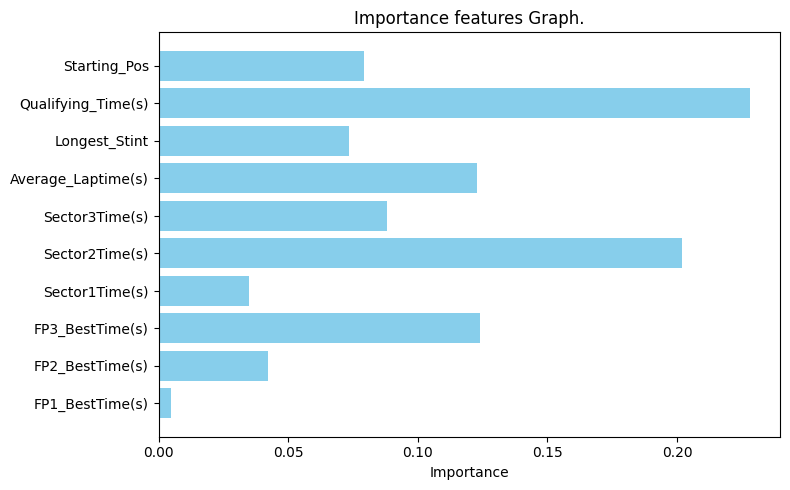

In [19]:
plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Importance features Graph.")
plt.tight_layout()
plt.show()

In [20]:
Jap

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_Laptime(s),Longest_Stint,Qualifying_Time(s),Starting_Pos,rain_probability,Temprature,Tyre_Compound_MEDIUM,Tyre_Compound_SOFT
0,ALB,93.697,91.4960,91.733,42.531231,48.057667,21.567000,106.666583,11.0,91.088,17.0,0,14.79,True,False
1,ANT,91.692,90.2250,89.362,47.109174,45.386107,21.655821,103.388474,10.0,88.778,1.0,0,14.79,True,False
2,BEA,92.900,91.4980,91.558,43.953800,45.669714,22.014214,102.402952,15.0,91.090,18.0,0,14.79,True,False
3,BOR,92.759,91.9330,91.000,53.260667,48.081545,24.916545,119.585250,7.0,90.274,9.0,0,14.79,False,True
4,BOT,94.490,92.6150,92.503,43.989200,47.002679,21.424036,109.386375,15.0,92.330,20.0,0,14.79,True,False
5,COL,93.361,92.4380,91.759,43.006280,47.661536,21.347107,104.757091,14.0,90.627,15.0,0,14.79,True,False
6,GAS,92.978,91.7340,91.082,41.008560,46.617310,21.627517,106.528667,13.0,89.691,7.0,0,14.79,False,False
7,HAD,92.803,91.7590,91.094,45.154038,46.109931,21.571241,106.243957,14.0,89.978,8.0,0,14.79,False,False
8,HAM,92.040,90.9800,90.383,46.753333,49.164185,22.050000,104.465000,9.0,89.567,6.0,0,14.79,True,False
9,HUL,92.798,91.4410,90.658,42.662375,45.554074,22.005074,104.905045,8.0,90.387,13.0,0,14.79,False,False


In [21]:
X = Jap.drop(columns=['Driver','rain_probability','Temprature','Tyre_Compound_MEDIUM','Tyre_Compound_SOFT'])


In [22]:
y_predict = regcv.predict(X)

In [23]:
Final = Jap.copy()
Final['Predicted'] = y_predict

In [24]:
Final = Final.sort_values(by=['Predicted'])

In [25]:
Final = Final.reset_index(drop=True)
Final['Predicted_Pos'] = Final.index+1

In [26]:
Final

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_Laptime(s),Longest_Stint,Qualifying_Time(s),Starting_Pos,rain_probability,Temprature,Tyre_Compound_MEDIUM,Tyre_Compound_SOFT,Predicted,Predicted_Pos
0,LIN,92.665,91.5982,91.288,44.565132,69.262000,38.967000,106.992398,1.0,90.319,10.0,0,14.79,True,False,12.88,1
1,STR,95.294,93.9510,93.485,44.378000,47.618476,21.998000,114.290000,7.0,92.920,22.0,0,14.79,False,True,12.88,2
2,BOR,92.759,91.9330,91.000,53.260667,48.081545,24.916545,119.585250,7.0,90.274,9.0,0,14.79,False,True,13.00,3
3,COL,93.361,92.4380,91.759,43.006280,47.661536,21.347107,104.757091,14.0,90.627,15.0,0,14.79,True,False,13.08,4
4,LAW,92.529,91.5900,91.097,42.420000,47.320533,21.645833,107.318542,14.0,90.495,14.0,0,14.79,True,False,13.08,5
5,PER,94.221,93.6890,92.540,47.314417,45.573786,22.538429,106.543600,9.0,92.206,19.0,0,14.79,False,False,13.08,6
6,HUL,92.798,91.4410,90.658,42.662375,45.554074,22.005074,104.905045,8.0,90.387,13.0,0,14.79,False,False,13.08,7
7,ALB,93.697,91.4960,91.733,42.531231,48.057667,21.567000,106.666583,11.0,91.088,17.0,0,14.79,True,False,13.08,8
8,SAI,93.383,91.6080,91.829,42.486538,46.049067,20.790467,105.217167,12.0,91.033,16.0,0,14.79,False,False,13.08,9
9,HAM,92.040,90.9800,90.383,46.753333,49.164185,22.050000,104.465000,9.0,89.567,6.0,0,14.79,True,False,13.32,10


In [27]:
podium = Final.loc[:,["Driver"]]
print("\n Predicted Standing")
print(f"🥇P1: {podium.iloc[0]['Driver']}")
print(f"🥈P2: {podium.iloc[1]['Driver']}")
print(f"🥉P3: {podium.iloc[2]['Driver']}")
print(f"P4: {podium.iloc[3]['Driver']}")
print(f"P5: {podium.iloc[4]['Driver']}")
print(f"P6: {podium.iloc[5]['Driver']}")
print(f"P7: {podium.iloc[6]['Driver']}")
print(f"P8: {podium.iloc[7]['Driver']}")
print(f"P9: {podium.iloc[8]['Driver']}")
print(f"P10: {podium.iloc[9]['Driver']}")
print(f"P11: {podium.iloc[10]['Driver']}")
print(f"P12: {podium.iloc[11]['Driver']}")

print(f"Spearman Rank (Predicted): {corr:.2f}")


 Predicted Standing
🥇P1: LIN
🥈P2: STR
🥉P3: BOR
P4: COL
P5: LAW
P6: PER
P7: HUL
P8: ALB
P9: SAI
P10: HAM
P11: LEC
P12: HAD
Spearman Rank (Predicted): 0.66
